## A notebook for testing the seir equations with a forward Euler and a Monte Carlo model.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import monte_carlo.seir_monte_carlo as mc
import forward_euler.seir_forward_euler as f

### Input Parameters:

In [14]:
shared_parameters = {
    "s_0": 0.99,
    "e_0": 0.01,
    "i_0": 0.0,
    "r_0": 0.0,
    "beta": 1.0,
    "sigma": 1,
    "gamma": 0.1
}

# Forward Euler parameters
step = 0.1
t_final = 100
f_euler_output = "f_euler_seir_data.csv"

# Monte Carlo parameters
length = 100
agent_count = 250
MCS = 2000
mc_output = "mc_seir_data.csv"

### Forward Euler simulation

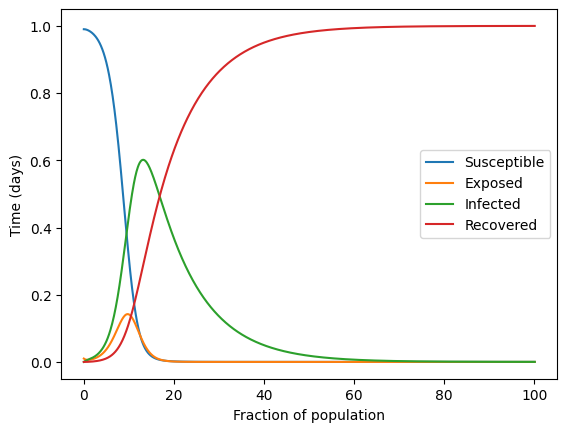

In [15]:
f.forward_euler(**shared_parameters, step=step, t_final=t_final, filename=f_euler_output)
f_euler_df = pd.read_csv(f_euler_output)

fig, ax = plt.subplots()

seir_labels = ["susceptible", "exposed", "infected", "recovered"]

for label in seir_labels:
    ax.plot(f_euler_df.iloc[:,0], f_euler_df[label], label=label.capitalize()) # Plotting each population category on the same ax

ax.set_xlabel("Fraction of population")
ax.set_ylabel("Time (days)")
ax.legend()

plt.show()

### Monte Carlo simulation

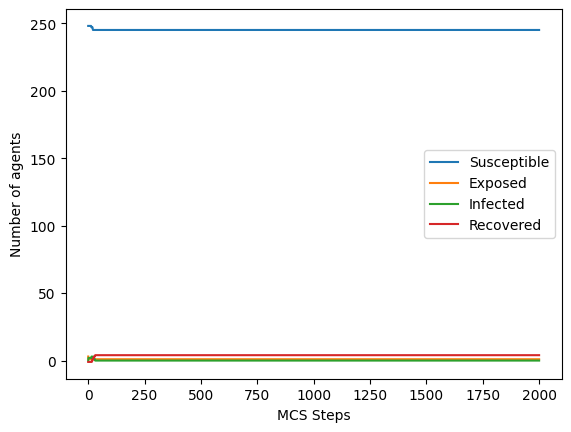

In [16]:
sim = mc.System(**shared_parameters, length=length, agent_count=agent_count)
sim.run_sim(MCS=MCS, filename=mc_output) # Initialising and running sim
mc_df = pd.read_csv(mc_output)

fig, ax = plt.subplots()

seir_labels = ["susceptible", "exposed", "infected", "recovered"]

for label in seir_labels:
    ax.plot(mc_df.iloc[:,0], mc_df[label], label=label.capitalize()) # Plotting each population category on the same ax

ax.set_xlabel("MCS Steps")
ax.set_ylabel("Number of agents")
ax.legend()

plt.show()